In [49]:
import seaborn as sns

titanic = sns.load_dataset("titanic")

titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [50]:
titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


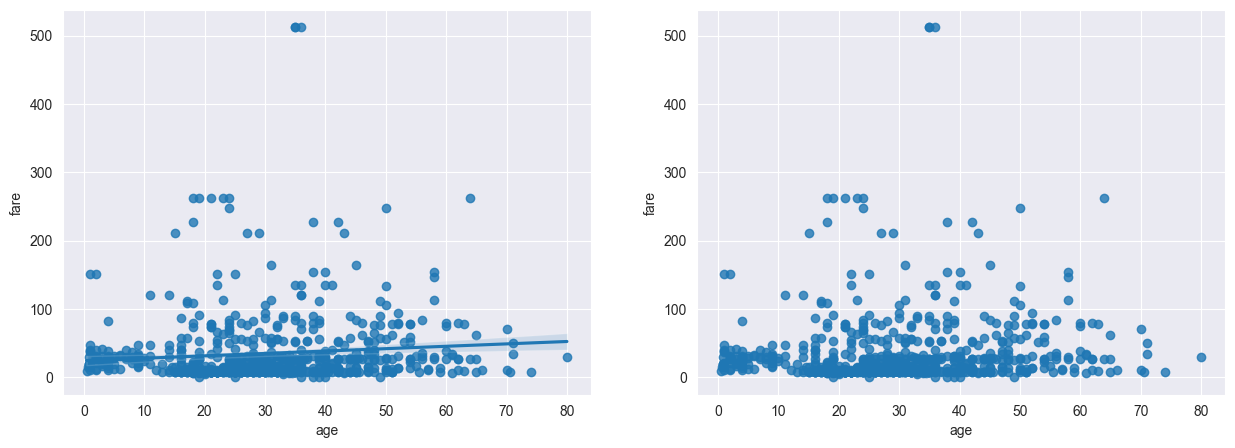

In [51]:
## 회귀선이 있는 산점도
import matplotlib.pyplot as plt
import seaborn as sns

titanic = sns.load_dataset("titanic")

sns.set_style("darkgrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.regplot(
    x="age", 
    y="fare", 
    data=titanic, 
    ax=axes[0]
)

sns.regplot(
    x="age", 
    y="fare", 
    data=titanic, 
    ax=axes[1],
    fit_reg=False
)

plt.show()

In [52]:
titanic["survived"].value_counts()

survived
0    549
1    342
Name: count, dtype: int64

<Axes: label='bottom', xlabel='age', ylabel='Count'>

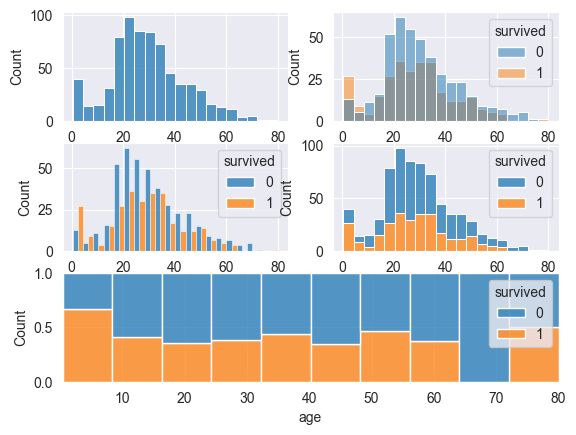

In [53]:
## 히스토그램 / 커널 밀도 그래프
fig, axes = plt.subplot_mosaic(
    [
        ["top_left", "top_right"], 
        ["middle_left", "middle_right"], 
        ["bottom", "bottom"]
    ]
)

sns.histplot(x="age", data=titanic, ax=axes["top_left"])
sns.histplot(x="age", data=titanic, ax=axes["top_right"],   hue="survived")
sns.histplot(x="age", data=titanic, ax=axes["middle_left"], hue="survived", multiple="dodge")
sns.histplot(x="age", data=titanic, ax=axes["middle_right"], hue="survived", multiple="stack")
sns.histplot(x="age", data=titanic, ax=axes["bottom"], hue="survived", multiple="fill", bins=10)

<Axes: label='right', xlabel='age', ylabel='Density'>

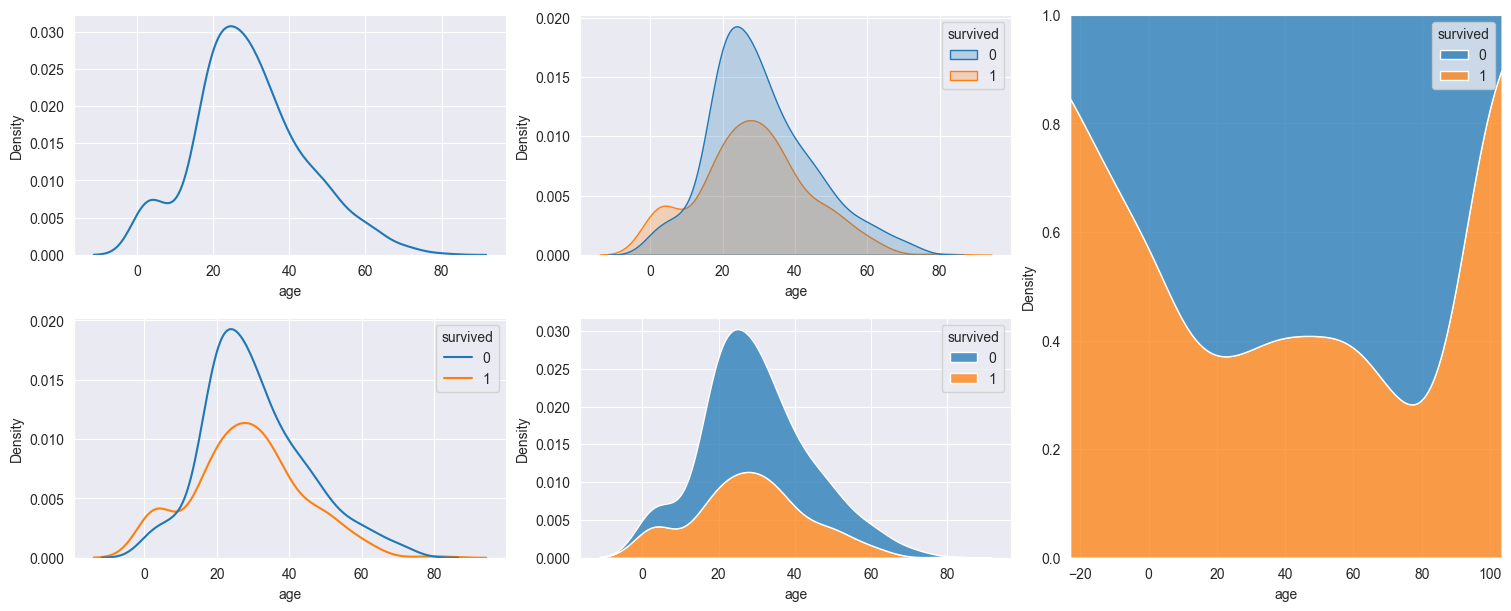

In [54]:
fig, axes = plt.subplot_mosaic([
    ["top_left", "top_center", "right"], 
    ["bottom_left", "bottom_center", "right"]
], 
figsize=(15, 6), 
constrained_layout=True
)

sns.kdeplot(x="age", data=titanic, ax=axes["top_left"])
sns.kdeplot(x="age", data=titanic, ax=axes["bottom_left"], hue="survived")
sns.kdeplot(x="age", data=titanic, ax=axes["top_center"], hue="survived", fill=True)
sns.kdeplot(x="age", data=titanic, ax=axes["bottom_center"], hue="survived", multiple="stack")
sns.kdeplot(x="age", data=titanic, ax=axes["right"], hue="survived", multiple="fill", bw_adjust=2.0)

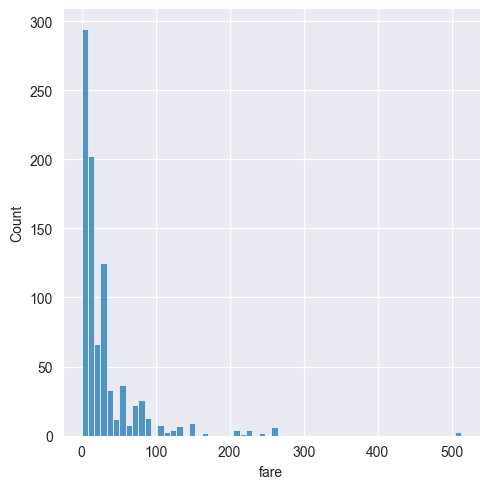

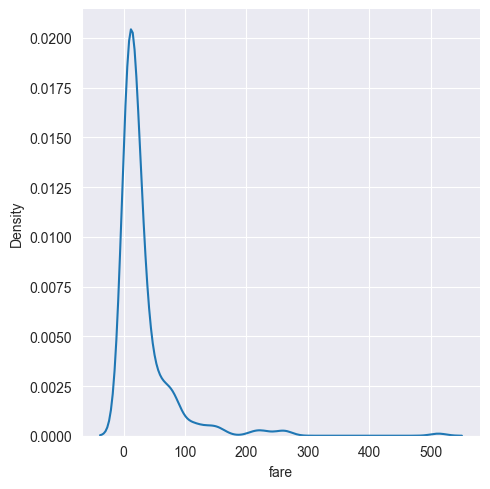

In [55]:
sns.displot(titanic["fare"], kind="hist")
plt.show()

sns.displot(titanic["fare"], kind="kde")
plt.show()

In [56]:
titanic["pclass"].value_counts()

pclass
3    491
1    216
2    184
Name: count, dtype: int64

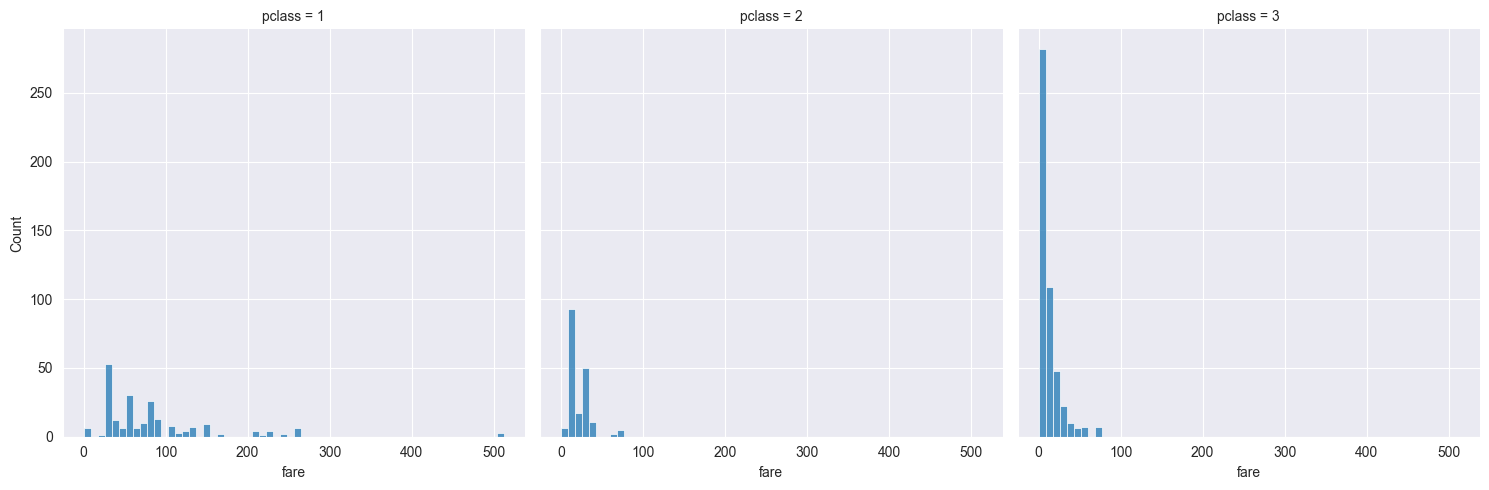

In [57]:
sns.displot(data=titanic, x="fare", col="pclass", kind="hist")

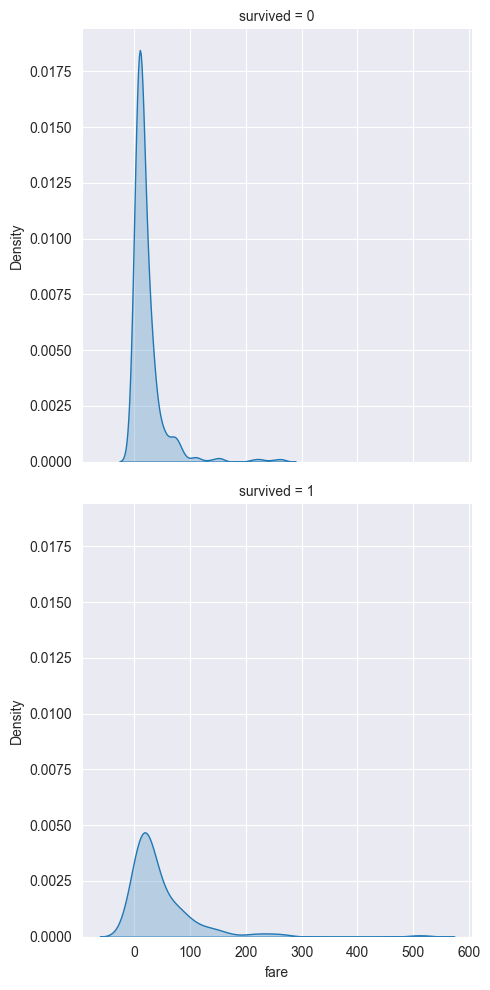

In [58]:
sns.displot(data=titanic, x="fare", row="survived", kind="kde", fill=True)

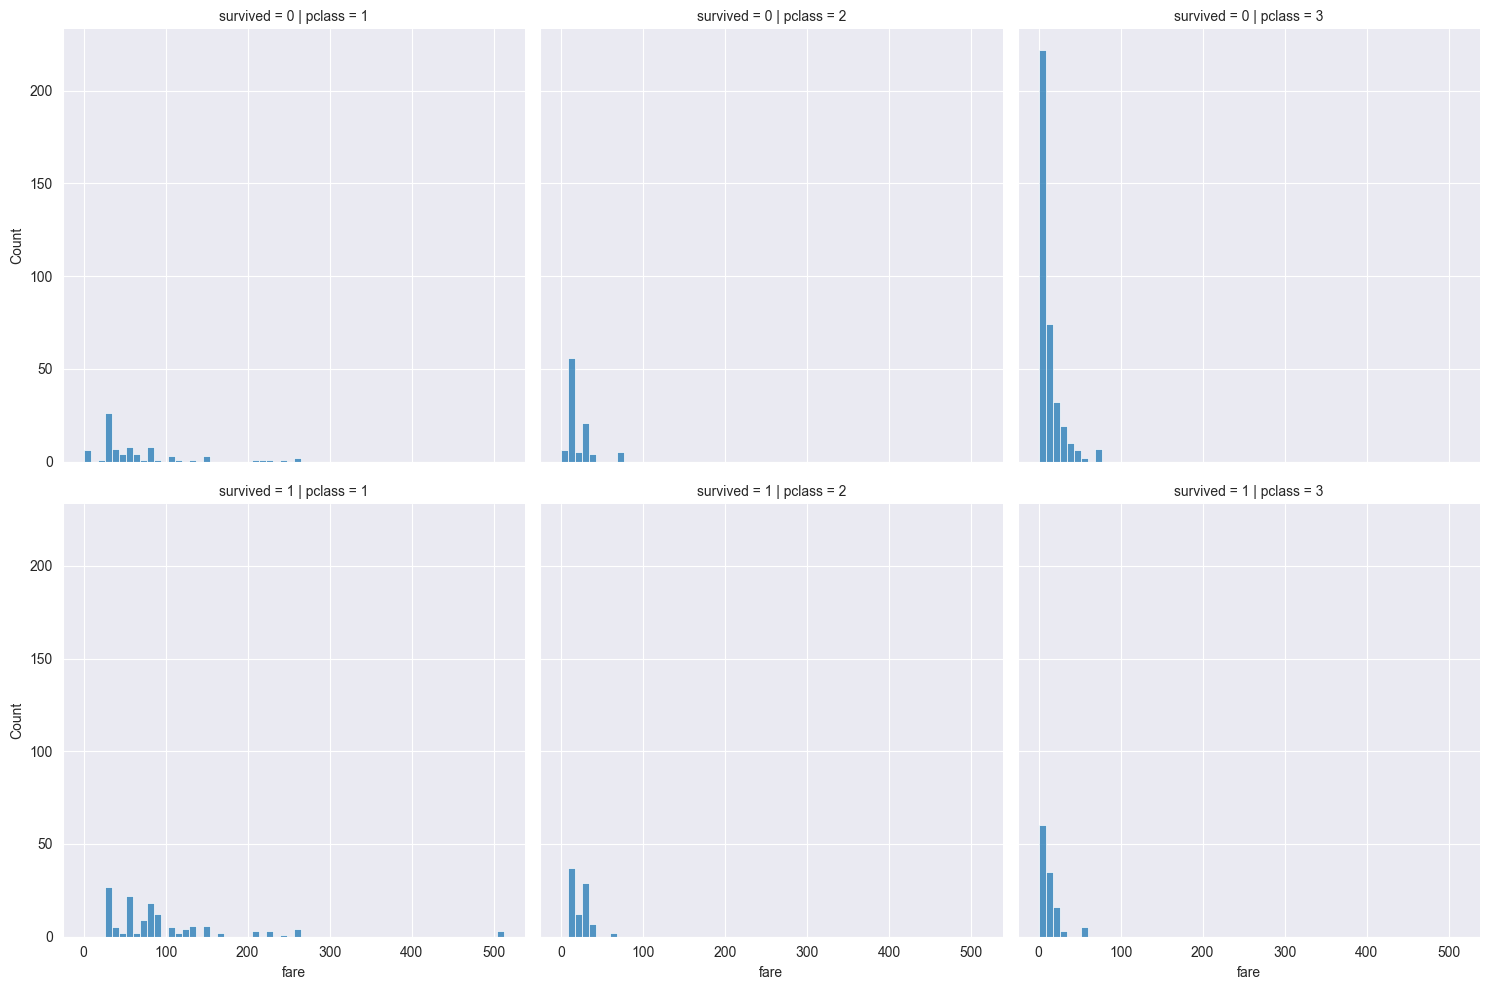

In [59]:
sns.displot(data=titanic, x="fare", col="pclass", row="survived")

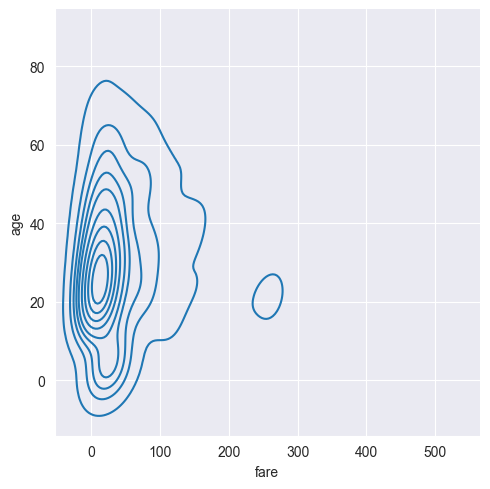

In [60]:
# 등고선차트 / 2d 히스토그램
sns.displot(x="fare", y="age", data=titanic, kind="kde")

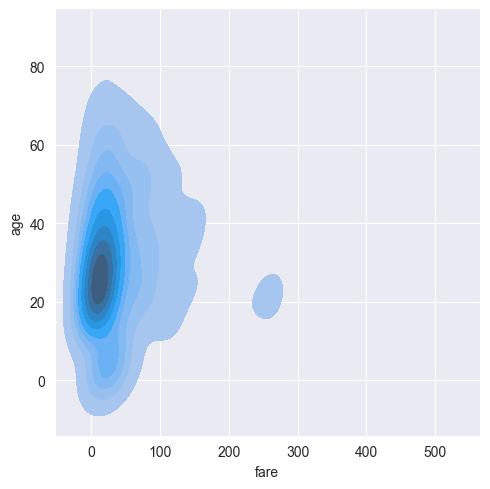

In [61]:
sns.displot(x="fare", y="age", data=titanic, kind="kde", fill=True)

In [62]:
# 히트맵
sns.set_style("darkgrid")

table = titanic.pivot_table(index=["sex"], columns=["class"], aggfunc="size", observed=False)
table

class,First,Second,Third
sex,,,
female,94,76,144
male,122,108,347


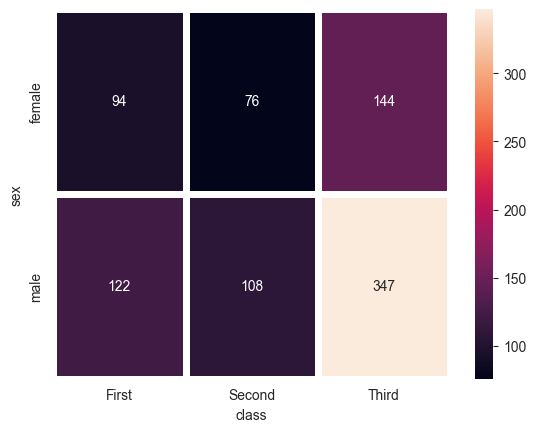

In [63]:
sns.heatmap(
    table, 
    annot=True, 
    fmt="d", 
    linewidth=5, 
    cbar=True
)

plt.show()

<Axes: xlabel='class', ylabel='age'>

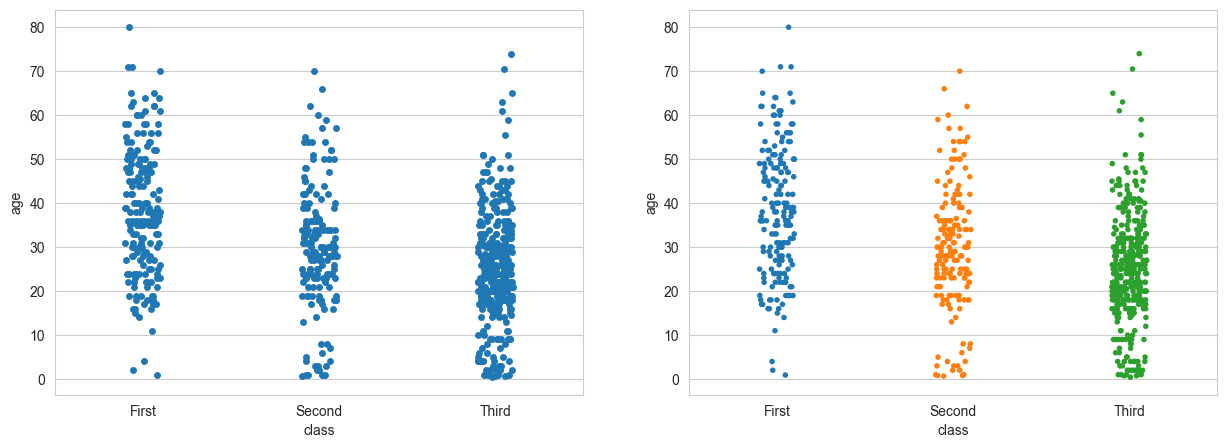

In [64]:
# 범주형 데이터의 산점도

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.stripplot(
    x="class", 
    y= "age", 
    data=titanic,
    ax=axes[0]
)

sns.stripplot(
    x="class", 
    y= "age", 
    data=titanic,
    ax=axes[1],
    size=4, 
    hue="class"
)

<Axes: xlabel='sex', ylabel='survived'>

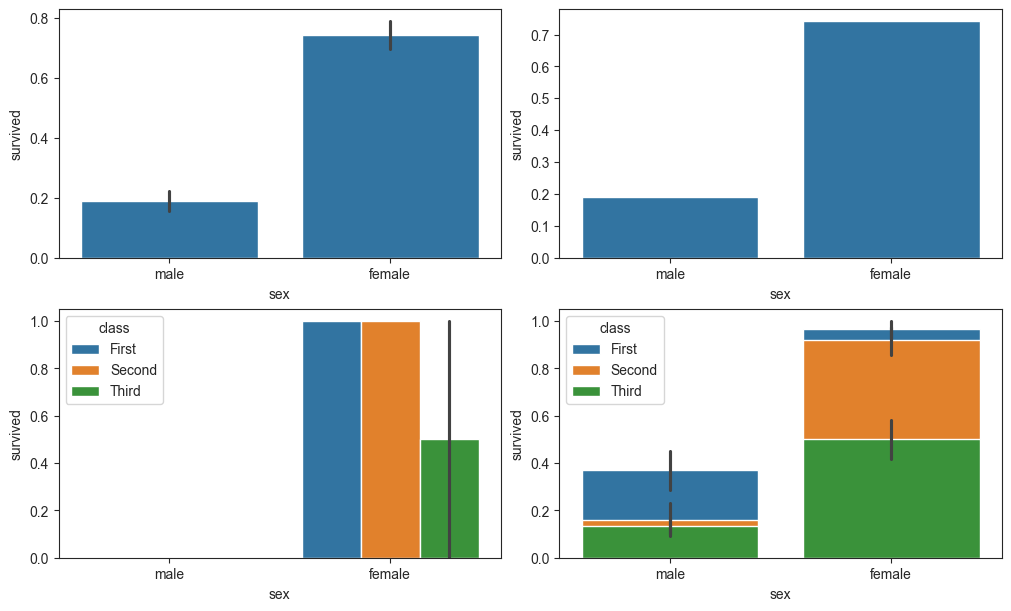

In [65]:
# 막대그래프 
sns.set_style("ticks")

fig, axes = plt.subplots(2, 2, figsize=(10, 6), constrained_layout=True)

sns.barplot(x="sex", y="survived", data=titanic, ax=axes[0,0])
sns.barplot(x="sex", y="survived", data=titanic, ax=axes[0,1], errorbar=None)
sns.barplot(x="sex", y="survived", data=titanic, ax=axes[1,0], errorbar=("ci", 95), hue="class", estimator="median")
sns.barplot(x="sex", y="survived", data=titanic, ax=axes[1,1], hue="class", dodge=False)

In [66]:
titanic["who"].value_counts()

who
man      537
woman    271
child     83
Name: count, dtype: int64

C:\Users\PC\AppData\Local\Temp\ipykernel_11552\2778301268.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=titanic, ax=axes[3], palette="Set3")


<Axes: xlabel='class', ylabel='count'>

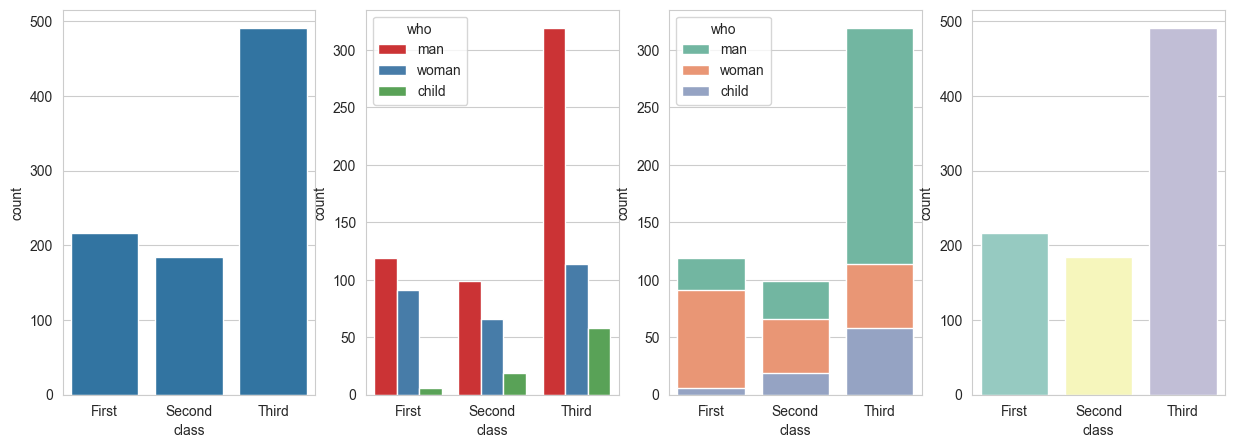

In [78]:
# 빈도그래프 

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 4, figsize=(15, 5))

sns.countplot(x="class", data=titanic, ax=axes[0])
sns.countplot(x="class", data=titanic, ax=axes[1], hue="who", palette="Set1", dodge=True)
sns.countplot(x="class", data=titanic, ax=axes[2], hue="who", palette="Set2", dodge=False)
sns.countplot(x="class", data=titanic, ax=axes[3], palette="Set3")

<Axes: xlabel='alive', ylabel='age'>

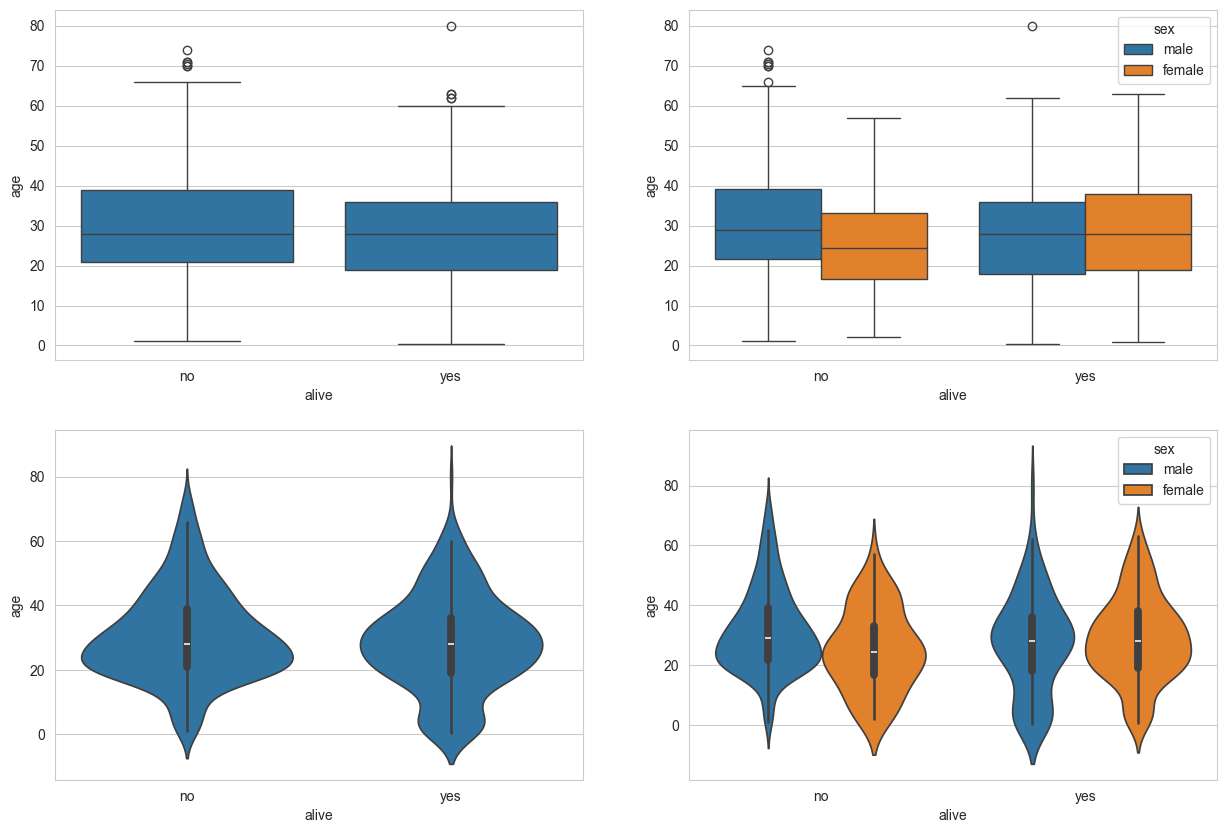

In [82]:
# 박스 플롯/바이올린 그래프

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(x="alive", y="age", data=titanic, ax=axes[0,0])
sns.boxplot(x="alive", y="age", data=titanic, ax=axes[0,1], hue="sex")

sns.violinplot(x="alive", y="age", data=titanic, ax=axes[1, 0])
sns.violinplot(x="alive", y="age", data=titanic, ax=axes[1, 1], hue="sex")


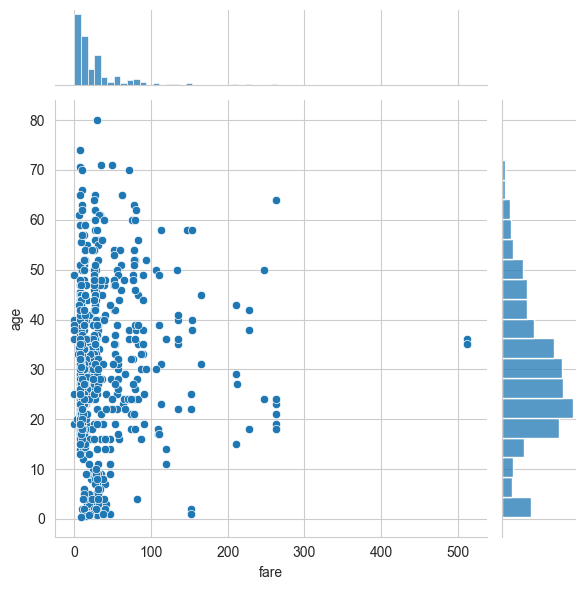

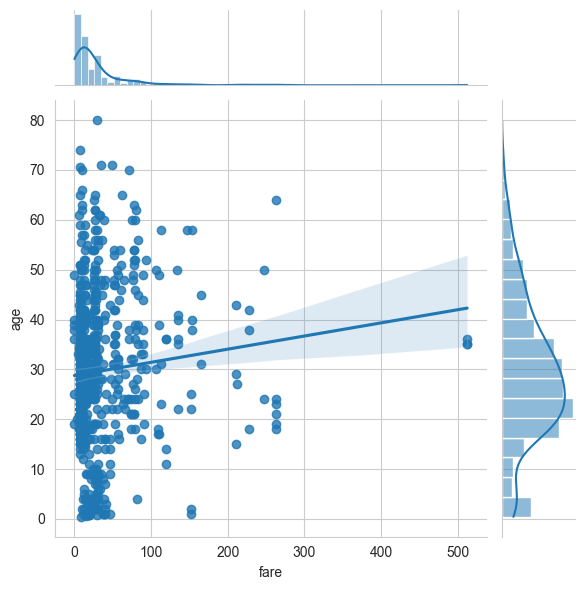

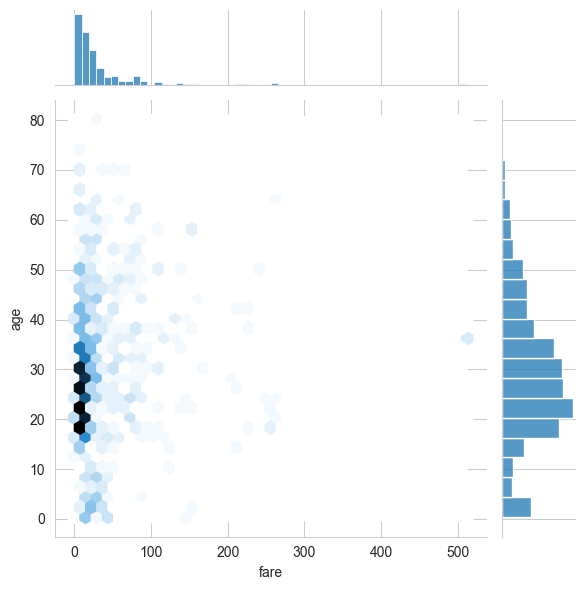

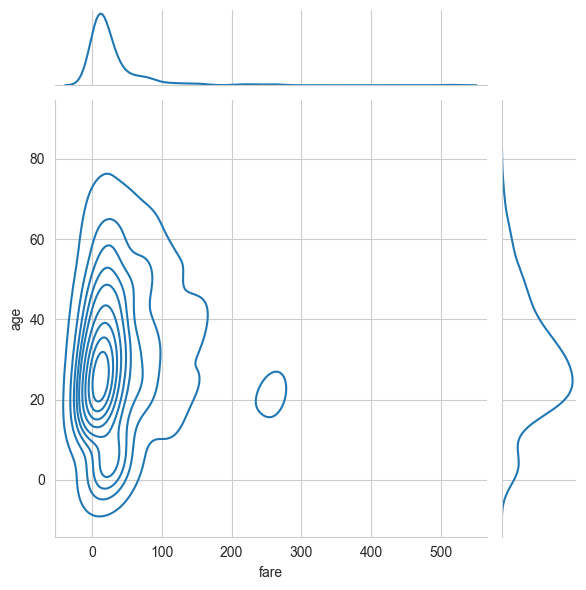

In [86]:
# 조인트 그래프

j1 = sns.jointplot(x="fare", y="age", data=titanic)
j2 = sns.jointplot(x="fare", y="age", data=titanic, kind="reg")
j3 = sns.jointplot(x="fare", y="age", data=titanic, kind="hex")
j3 = sns.jointplot(x="fare", y="age", data=titanic, kind="kde")

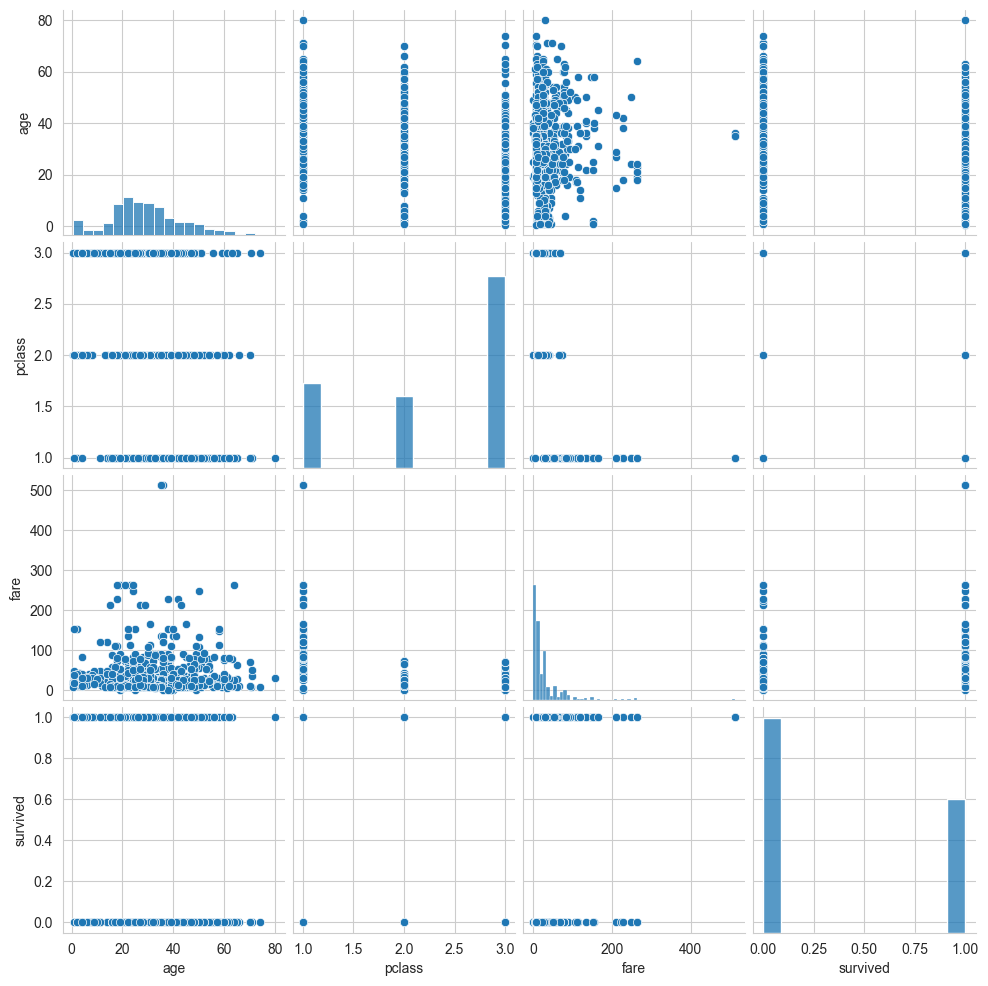

In [90]:
# 화면을 그리드로 분할하기 

titanic_pair = titanic[["age", "pclass", "fare", "survived"]]

g = sns.pairplot(titanic_pair)


In [91]:
# forlium 라이브러리 

import folium

seoul_map = folium.Map(location=[37.55, 126.98], zoom_start=12)

seoul_map



In [92]:
seoul_map.save("./data/seoul2.html")